In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

/home/tristan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
dt = pd.read_csv("dataset.csv")
dt

,Unnamed: 0,Age,Menopause,Taille_tumeur,Ganglions_touches,Metastases,Grade,Lateralite,Quadrant,Irradiation,Recidive
0,1,NaN,1.0,NaN,NaN,2.0,3.0,NaN,3.0,1,NaN
1,2,51.240996,2.0,16.874618,1.0,1.0,1.0,2.0,1.0,1,1.0
2,3,NaN,2.0,NaN,NaN,1.0,NaN,NaN,2.0,1,NaN
3,4,NaN,1.0,25.608588,NaN,NaN,2.0,NaN,NaN,NaN,1.0
4,5,55.254881,2.0,43.438748,2.0,1.0,3.0,1.0,3.0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...
297,2651,52.048990,2.0,33.089490,11.0,NaN,3.0,1.0,2.0,2,1.0
298,308,75.745550,2.0,15.239369,9.0,NaN,1.0,1.0,2.0,2,2.0
299,347,54.688155,2.0,23.642077,2.0,NaN,1.0,1.0,2.0,1,2.0
300,378,57.920124,2.0,22.087332,2.0,NaN,1.0,1.0,3.0,1,2.0


In [3]:
dt = dt.drop("Unnamed: 0", axis="columns", inplace=False)

In [4]:
dt.dtypes

Age                  float64
Menopause            float64
Taille_tumeur        float64
Ganglions_touches    float64
Metastases           float64
Grade                float64
Lateralite           float64
Quadrant             float64
Irradiation           object
Recidive             float64
dtype: object

In [5]:
dt.isnull().sum()

Age                  110
Menopause             40
Taille_tumeur        106
Ganglions_touches     81
Metastases            76
Grade                 78
Lateralite            57
Quadrant              87
Irradiation           65
Recidive             136
dtype: int64

In [6]:
dt

,Age,Menopause,Taille_tumeur,Ganglions_touches,Metastases,Grade,Lateralite,Quadrant,Irradiation,Recidive
0,NaN,1.0,NaN,NaN,2.0,3.0,NaN,3.0,1,NaN
1,51.240996,2.0,16.874618,1.0,1.0,1.0,2.0,1.0,1,1.0
2,NaN,2.0,NaN,NaN,1.0,NaN,NaN,2.0,1,NaN
3,NaN,1.0,25.608588,NaN,NaN,2.0,NaN,NaN,NaN,1.0
4,55.254881,2.0,43.438748,2.0,1.0,3.0,1.0,3.0,1,1.0
...,...,...,...,...,...,...,...,...,...,...
297,52.048990,2.0,33.089490,11.0,NaN,3.0,1.0,2.0,2,1.0
298,75.745550,2.0,15.239369,9.0,NaN,1.0,1.0,2.0,2,2.0
299,54.688155,2.0,23.642077,2.0,NaN,1.0,1.0,2.0,1,2.0
300,57.920124,2.0,22.087332,2.0,NaN,1.0,1.0,3.0,1,2.0


<h4>To see if there's no relevant Age data</h4>

Text(0.5, 1.0, "Densité des observations concernant l'âge du patient")

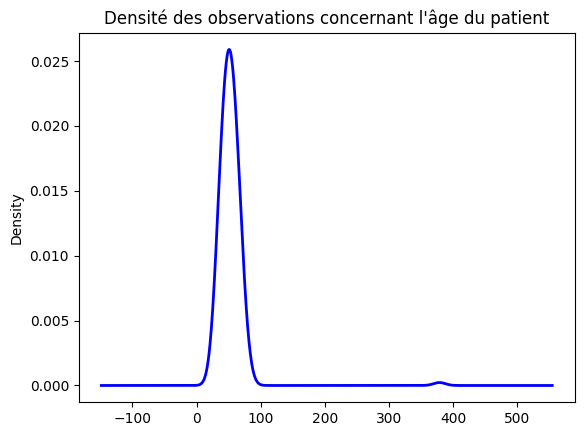

In [7]:
dt["Age"].plot.density(bw_method='scott', color='blue', linestyle='-', linewidth=2)
plt.title("Densité des observations concernant l'âge du patient")

In [8]:
dt["Age"].describe()

count    192.000000
mean      53.059182
std       26.269277
min       27.269382
25%       43.416635
50%       52.367426
75%       58.709683
max      378.787350
Name: Age, dtype: float64

<h4>To see if there's more than 2 values for the menopause and 3 for the grade</h4>

In [9]:
dt["Menopause"].value_counts()

Menopause
1.0    135
2.0    127
Name: count, dtype: int64

In [10]:
#We good fot the menopause variable

In [11]:
dt.Grade.value_counts()

Grade
2.0     97
3.0     72
1.0     54
34.0     1
Name: count, dtype: int64

In [12]:
#We only have 1 record with the observation 34. We can suppose that the doctor type 34 by mistake. The one wanted was probably 3

<h5>No the correlation between the age and the menopause</h5>

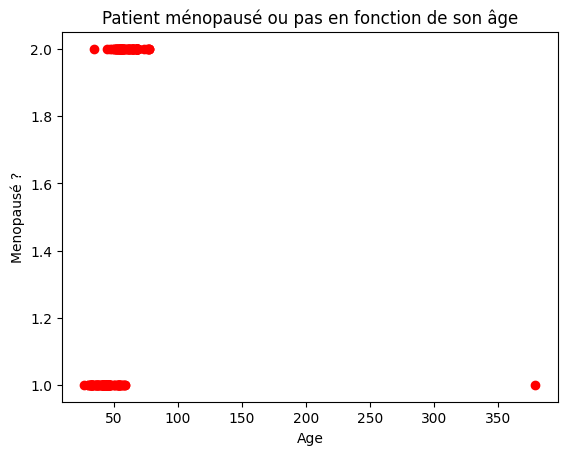

In [19]:
plt.scatter(dt["Age"], dt["Menopause"], color="red")
plt.title("Patient ménopausé ou pas en fonction de son âge")
plt.xlabel("Age")
plt.ylabel("Menopausé ?")
plt.show()

In [14]:
#The values of age are very close so the scatter plot doesn't give much information. We can't see clearly if there's a pattern

<h4>Tumor size density</h4>

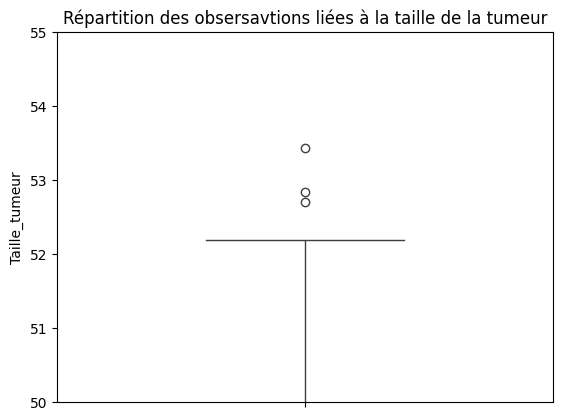

In [15]:
sns.boxplot(data = dt["Taille_tumeur"])
plt.ylim(50, 55)
plt.title("Répartition des obsersavtions liées à la taille de la tumeur")
plt.show()

In [16]:
dt["Taille_tumeur"].describe()

count    196.000000
mean      26.127106
std       10.389460
min        1.714647
25%       18.812693
50%       26.549199
75%       32.257666
max       53.422745
Name: Taille_tumeur, dtype: float64

In [17]:
#Un graphique Q-Q (Quantile-Quantile) est utilisé pour vérifier si un ensemble de données suit une distribution théorique particulière.
#QQPlot on tumor size + Shapiro test to see if it rejects null hypotesis ( pvalue > 0.5 )

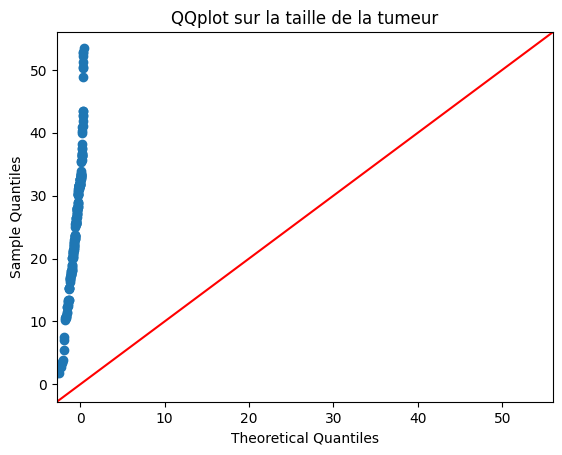

In [20]:
import statsmodels.api as sm
import pylab as py

sm.qqplot(dt["Taille_tumeur"], line = '45')
py.title("QQplot sur la taille de la tumeur")
py.show()

In [23]:
from scipy.stats import shapiro

rounded = dt
shapiroo = shapiro(rounded["Taille_tumeur"])
shapiroo

ShapiroResult(statistic=np.float64(nan), pvalue=np.float64(nan))

In [24]:
#It doesn't work with Null Values
rounded = rounded.dropna(subset=["Taille_tumeur"])
rounded

,Age,Menopause,Taille_tumeur,Ganglions_touches,Metastases,Grade,Lateralite,Quadrant,Irradiation,Recidive
1,51.240996,2.0,16.874618,1.0,1.0,1.0,2.0,1.0,1,1.0
3,NaN,1.0,25.608588,NaN,NaN,2.0,NaN,NaN,NaN,1.0
4,55.254881,2.0,43.438748,2.0,1.0,3.0,1.0,3.0,1,1.0
5,46.298965,1.0,10.601184,2.0,1.0,2.0,1.0,3.0,1,1.0
9,56.972747,2.0,30.606762,0.0,NaN,NaN,2.0,NaN,1,NaN
...,...,...,...,...,...,...,...,...,...,...
297,52.048990,2.0,33.089490,11.0,NaN,3.0,1.0,2.0,2,1.0
298,75.745550,2.0,15.239369,9.0,NaN,1.0,1.0,2.0,2,2.0
299,54.688155,2.0,23.642077,2.0,NaN,1.0,1.0,2.0,1,2.0
300,57.920124,2.0,22.087332,2.0,NaN,1.0,1.0,3.0,1,2.0


In [25]:
shapiroo = shapiro(rounded["Taille_tumeur"])
shapiroo

ShapiroResult(statistic=np.float64(0.9834111157624116), pvalue=np.float64(0.0205546977172848))

In [26]:
#P_value < 0.05 so we reject null hypothesis. Like the QQPlot shows us, the tumor size is not following the normal law

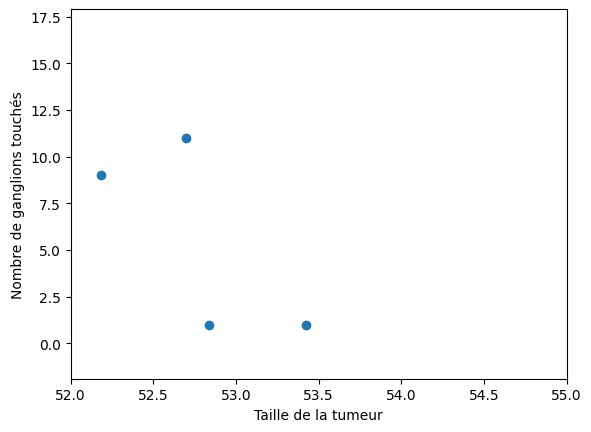

In [28]:
plt.scatter(dt["Taille_tumeur"], dt["Ganglions_touches"])
plt.xlim(52,55)
plt.xlabel("Taille de la tumeur")
plt.ylabel("Nombre de ganglions touchés")
plt.show()

<h3>Ganglions touchés</h3>

In [29]:
import seaborn as sns

<Axes: ylabel='Ganglions_touches'>

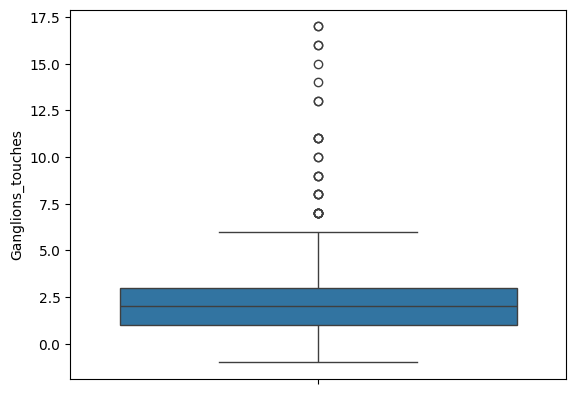

In [30]:
sns.boxplot(data = dt["Ganglions_touches"])

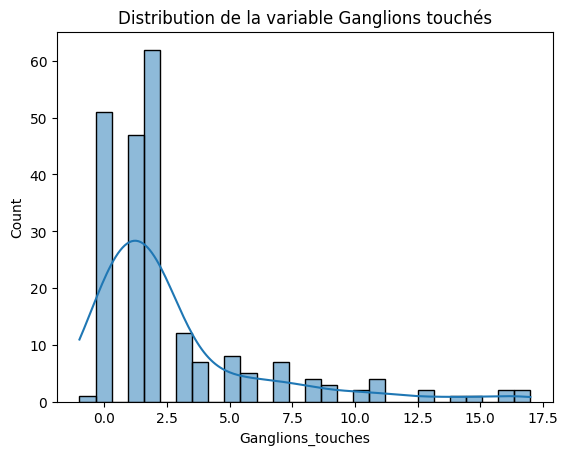

In [31]:
sns.histplot(dt["Ganglions_touches"], kde=True)
plt.title("Distribution de la variable Ganglions touchés")
plt.show()

In [32]:
dt[dt["Ganglions_touches"] < 0].head()
#Nous pouvons voir qu'un patient possède une valeur négative

,Age,Menopause,Taille_tumeur,Ganglions_touches,Metastases,Grade,Lateralite,Quadrant,Irradiation,Recidive
76,65.114903,2.0,31.212433,-1.0,1.0,2.0,1.0,2.0,2,1.0


In [33]:
#Comme nous avons des valeurs <= 0, nous ne pouvons pas faire BoxCox ( log(x) et log(0) existe pas )
#Nous faisons donc Yeo-Johnson

In [34]:
#De plus, avoir plus de 10 ganglions touché pour un patient est rare.
#Mais pas imposible.Pour savoir si notre observation est aberrantes, nous allons la comparer avec la taille de la tumeur. 
#Si beaucoup de ganglions touchés mais une taille de tumeur petite, nous pouvons conclure que c'est une erreur.

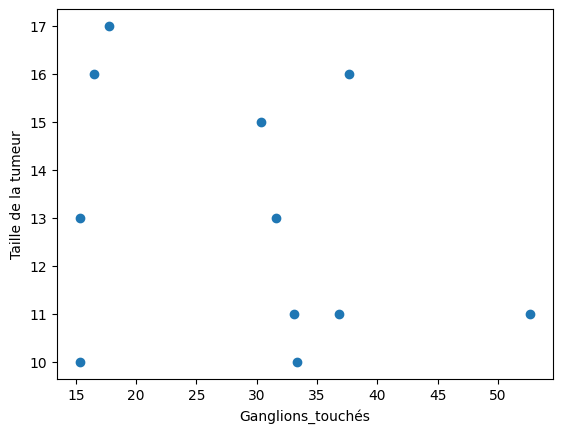

In [35]:
big_ganglions = dt[dt["Ganglions_touches"] > 9]
plt.scatter(big_ganglions["Taille_tumeur"], big_ganglions["Ganglions_touches"])
plt.xlabel("Ganglions_touchés")
plt.ylabel("Taille de la tumeur")
plt.show()

In [36]:
#Aucun lien, aucun cluster, les variables sont indépendantes

<h4>Metastases</h4>

In [37]:
dt["Metastases"].value_counts() 
# 1 = Metastase visible
# 2 = Metastase non visible
# Autre = Valeur aberrante

Metastases
1.0    178
2.0     48
Name: count, dtype: int64

<h4>Grade</h4>

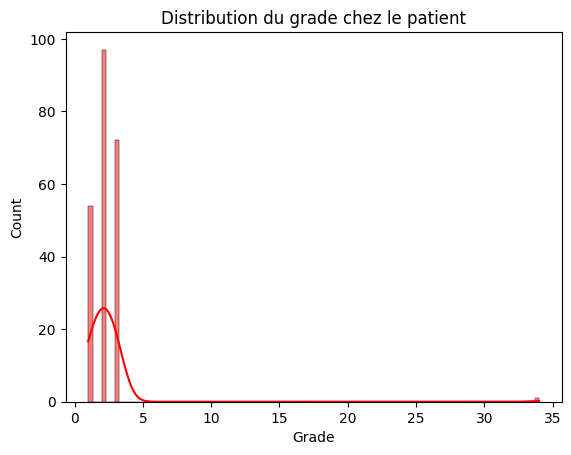

In [38]:
sns.histplot(dt["Grade"], kde=True, color="red")
plt.title("Distribution du grade chez le patient")
plt.show()

In [39]:
#We can see a dot near the 35.
#So we look in detail
dt['Grade'].value_counts()

Grade
2.0     97
3.0     72
1.0     54
34.0     1
Name: count, dtype: int64

<h4>Lateralité</h4>

In [40]:
#Valeur possible : 1 & 2
# 1 -> cancer sein gauche
# 2 -> cancr sein droit
#Autre -> Ano

dt["Lateralite"].value_counts()

Lateralite
1.0    131
2.0    114
Name: count, dtype: int64

<h4>Quadrant</h4>

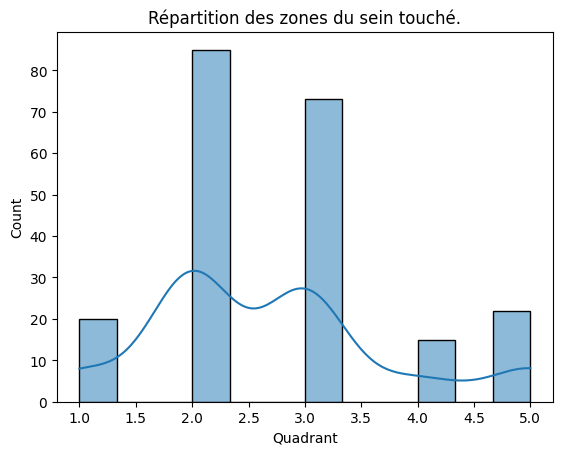

In [41]:
sns.histplot(dt["Quadrant"], kde=True)
plt.title("Répartition des zones du sein touché.")
plt.show()

<h4>Irradiation</h4>

In [42]:
dt["Irradiation"] = pd.to_numeric(dt["Irradiation"], errors='coerce')

In [43]:
#We think if tumor size < 5 cm & ganglions touché = 0 --> no irradiation ( cause small )
#First of all let's check if irraidtion != 1 or != 2

dt.Irradiation.value_counts()

Irradiation
1.0    177
2.0     59
Name: count, dtype: int64

<h4>Recidive</h4>

In [44]:
dt.Recidive.value_counts()

Recidive
1.0    101
2.0     65
Name: count, dtype: int64

In [45]:
#Recap valeurs aberantes:
#Age -> 1 observation ; 378
#Grade -> 1 observation : 34
#Ganglion_touche -> 1 observation : -1